# Final Model Evaluation

This notebook is self-contained and reproduces the final comparison of
the three machine-learning classifiers.

The models are:

1. Logistic regression
2. Gradient-boosted decision trees
3. A fully connected neural network

The final test sample is not used for model selection.

The primary performance metric is ROC-AUC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.__version__

'2.14.0+cpu'

## 2. Load the dataset

In [2]:
data_path = "../data/training.csv"

df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")

Dataset shape: (250000, 33)


## 3. Define features and target

The event identifier and event weight are not used as input features.

The target is:

- `0` = background
- `1` = signal

The `-999` sentinel values are converted to missing values.

In [3]:
feature_columns = [
    column
    for column in df.columns
    if column not in ["EventId", "Weight", "Label"]
]

X = df[feature_columns].replace(-999, np.nan)

y = (df["Label"] == "s").astype(int)

summary = pd.Series({
    "Number of features": len(feature_columns),
    "Number of events": len(X),
    "Signal fraction": y.mean(),
})

summary

Number of features        30.000000
Number of events      250000.000000
Signal fraction            0.342668
dtype: float64

## 4. Final development/test split

Twenty percent of the events are reserved as an independent test set.

The test set is not used for model selection or hyperparameter tuning.

In [4]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

pd.DataFrame({
    "Sample": ["Development", "Test"],
    "Events": [len(X_dev), len(X_test)],
    "Signal fraction": [y_dev.mean(), y_test.mean()],
})


,Sample,Events,Signal fraction
0,Development,200000,0.34267
1,Test,50000,0.34266


## 5. Logistic regression

A logistic-regression classifier provides the linear baseline.
Missing values are imputed and features are standardized within a
scikit-learn pipeline.

In [5]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
    )),
])

logistic_model.fit(X_dev, y_dev)

logistic_test_score = logistic_model.predict_proba(X_test)[:, 1]

logistic_test_auc = roc_auc_score(y_test, logistic_test_score)

print(f"Logistic regression test ROC-AUC: {logistic_test_auc:.4f}")

Logistic regression test ROC-AUC: 0.8123


## 6. Gradient-boosted decision trees

The selected boosted-tree configuration from the development study is
now trained on the full development sample.

In [6]:
tree_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42,
)

tree_model.fit(X_dev, y_dev)

tree_test_score = tree_model.predict_proba(X_test)[:, 1]

tree_test_auc = roc_auc_score(
    y_test,
    tree_test_score,
)

print(f"Boosted-tree test ROC-AUC: {tree_test_auc:.4f}")

Boosted-tree test ROC-AUC: 0.9088


## 7. Neural network

A small fully connected neural network is trained using the development
sample.

A validation subset is used during training, while the final test set
remains untouched until the final evaluation.

In [7]:
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    random_state=42,
    stratify=y_dev,
)

print("NN training:", X_train_nn.shape)
print("NN validation:", X_val_nn.shape)

NN training: (160000, 30)
NN validation: (40000, 30)


In [8]:
nn_imputer = SimpleImputer(strategy="median")
nn_scaler = StandardScaler()

X_train_nn_processed = nn_imputer.fit_transform(X_train_nn)
X_val_nn_processed = nn_imputer.transform(X_val_nn)
X_test_nn_processed = nn_imputer.transform(X_test)

X_train_nn_processed = nn_scaler.fit_transform(
    X_train_nn_processed
)

X_val_nn_processed = nn_scaler.transform(
    X_val_nn_processed
)

X_test_nn_processed = nn_scaler.transform(
    X_test_nn_processed
)

In [9]:
X_train_tensor = torch.tensor(
    X_train_nn_processed,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train_nn.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

X_val_tensor = torch.tensor(
    X_val_nn_processed,
    dtype=torch.float32,
)

y_val_tensor = torch.tensor(
    y_val_nn.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

X_test_tensor = torch.tensor(
    X_test_nn_processed,
    dtype=torch.float32,
)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

### Network architecture

The network contains two hidden layers with 64 and 32 neurons,
respectively, using ReLU activations.

In [10]:
class HiggsNetwork(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

In [11]:
nn_model = HiggsNetwork(
    n_features=X_train_tensor.shape[1]
)

nn_model

HiggsNetwork(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

### Training

In [12]:
loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    nn_model.parameters(),
    lr=0.001,
)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
)

In [13]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    loss_function,
):
    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = loss_function(
            logits,
            y_batch,
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(X_batch)

    return total_loss / len(loader.dataset)

In [14]:
def predict_probability(model, X):

    model.eval()

    with torch.no_grad():
        logits = model(X)
        probabilities = torch.sigmoid(logits)

    return probabilities.numpy().ravel()


def evaluate_auc(model, X, y):

    probabilities = predict_probability(
        model,
        X,
    )

    return roc_auc_score(
        y,
        probabilities,
    )

In [15]:
nn_loss_history = []
nn_train_auc_history = []
nn_val_auc_history = []

best_val_auc = -np.inf
best_state = None

patience = 3
epochs_without_improvement = 0
max_epochs = 30

for epoch in range(max_epochs):

    loss = train_one_epoch(
        nn_model,
        train_loader,
        optimizer,
        loss_function,
    )

    train_auc = evaluate_auc(
        nn_model,
        X_train_tensor,
        y_train_nn,
    )

    val_auc = evaluate_auc(
        nn_model,
        X_val_tensor,
        y_val_nn,
    )

    nn_loss_history.append(loss)
    nn_train_auc_history.append(train_auc)
    nn_val_auc_history.append(val_auc)

    print(
        f"Epoch {epoch + 1:2d} | "
        f"loss = {loss:.4f} | "
        f"train AUC = {train_auc:.4f} | "
        f"val AUC = {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc

        best_state = {
            key: value.detach().clone()
            for key, value in nn_model.state_dict().items()
        }

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping.")
            break

Epoch  1 | loss = 0.4935 | train AUC = 0.8799 | val AUC = 0.8794
Epoch  2 | loss = 0.3962 | train AUC = 0.8946 | val AUC = 0.8942
Epoch  3 | loss = 0.3837 | train AUC = 0.8976 | val AUC = 0.8967
Epoch  4 | loss = 0.3785 | train AUC = 0.8998 | val AUC = 0.8986
Epoch  5 | loss = 0.3744 | train AUC = 0.9018 | val AUC = 0.9001
Epoch  6 | loss = 0.3717 | train AUC = 0.9032 | val AUC = 0.9013
Epoch  7 | loss = 0.3687 | train AUC = 0.9044 | val AUC = 0.9021
Epoch  8 | loss = 0.3663 | train AUC = 0.9057 | val AUC = 0.9033
Epoch  9 | loss = 0.3644 | train AUC = 0.9062 | val AUC = 0.9031
Epoch 10 | loss = 0.3632 | train AUC = 0.9070 | val AUC = 0.9043
Epoch 11 | loss = 0.3618 | train AUC = 0.9083 | val AUC = 0.9052
Epoch 12 | loss = 0.3606 | train AUC = 0.9088 | val AUC = 0.9056
Epoch 13 | loss = 0.3595 | train AUC = 0.9093 | val AUC = 0.9059
Epoch 14 | loss = 0.3587 | train AUC = 0.9098 | val AUC = 0.9059
Epoch 15 | loss = 0.3580 | train AUC = 0.9100 | val AUC = 0.9063
Epoch 16 | loss = 0.3572 

In [16]:
nn_model.load_state_dict(best_state)

print(
    f"Best validation ROC-AUC: {best_val_auc:.4f}"
)

Best validation ROC-AUC: 0.9085


### Neural-network test performance

In [17]:
nn_test_score = predict_probability(
    nn_model,
    X_test_tensor,
)

nn_test_auc = roc_auc_score(
    y_test,
    nn_test_score,
)

print(f"Neural network test ROC-AUC: {nn_test_auc:.4f}")

Neural network test ROC-AUC: 0.9068


## 8. Final model comparison

All three models are now evaluated on the same independent test sample.

ROC-AUC is used as the primary comparison metric.

In [18]:
results = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "Gradient-boosted trees",
        "Neural network",
    ],
    "Test ROC-AUC": [
        logistic_test_auc,
        tree_test_auc,
        nn_test_auc,
    ],
})

results = results.sort_values(
    "Test ROC-AUC",
    ascending=False,
).reset_index(drop=True)

results

,Model,Test ROC-AUC
0,Gradient-boosted trees,0.908759
1,Neural network,0.906811
2,Logistic regression,0.812336


## 9. Final ROC curves

The ROC curves provide a visual comparison of the three classifiers
on the independent test sample.

In [19]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_test_score,
)

tree_fpr, tree_tpr, _ = roc_curve(
    y_test,
    tree_test_score,
)

nn_fpr, nn_tpr, _ = roc_curve(
    y_test,
    nn_test_score,
)

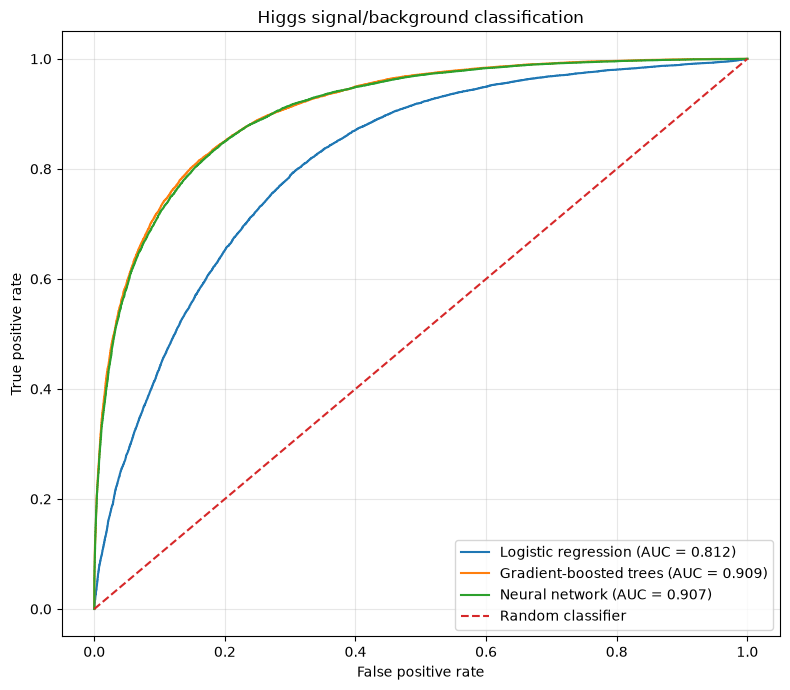

In [20]:
plt.figure(figsize=(8, 7))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic regression (AUC = {logistic_test_auc:.3f})",
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label=f"Gradient-boosted trees (AUC = {tree_test_auc:.3f})",
)

plt.plot(
    nn_fpr,
    nn_tpr,
    label=f"Neural network (AUC = {nn_test_auc:.3f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random classifier",
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Higgs signal/background classification")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/final_roc_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 10. Final evaluation

The independent test sample was not used for feature selection,
hyperparameter selection, early stopping, or model comparison during
development.

The final ROC-AUC values reported in Section 8 therefore correspond to
a single evaluation of the selected models on previously unseen events.

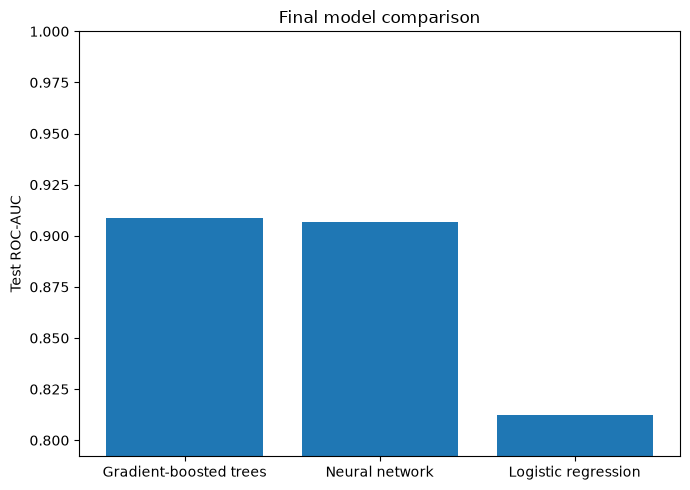

In [24]:
plt.figure(figsize=(7, 5))

plt.bar(
    results["Model"],
    results["Test ROC-AUC"],
)

plt.ylabel("Test ROC-AUC")
plt.title("Final model comparison")
plt.xticks(rotation=0)

plt.ylim(
    min(results["Test ROC-AUC"]) - 0.02,
    1.0,
)

plt.tight_layout()

plt.savefig(
    "../figures/final_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 11. Conclusions

This project investigated supervised machine learning for signal/background
classification using simulated Higgs-boson events.

Three approaches were compared:

1. logistic regression;
2. gradient-boosted decision trees;
3. a fully connected neural network.

Logistic regression provided a simple linear baseline, while the boosted-tree
and neural-network models were able to represent nonlinear relationships
between the event observables.

Model development was performed using separate training and validation
samples, while an independent test sample was kept untouched until the
final evaluation.

The analysis also illustrated practical machine-learning concepts including
missing-value handling, feature preprocessing, model comparison, feature
importance, overfitting, validation, early stopping, and neural-network
training.

For this introductory study, the objective was not to optimize the absolute
classification performance, but to understand and reproduce the complete
workflow from particle-physics data to a reproducible machine-learning
analysis.